In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as sci

In [22]:
# define our system PK

# x : passed as initials for A,C
    # A : amount in absorption compartment
    # C : amount in plasma
# t : time in sec
# th : half life t_{1/2}
# F : bioavailability
def cafPK(x, t, ka, th, Vd):
    A, C = x
    kel = np.log(2) / th # elimination
    dAdt = -ka * A
    dCdt = (ka * A / Vd) - (kel * C)
    return [dAdt, dCdt]

In [23]:
# params

# Caffeine pharmacokinetics
# Oral absorption model (1-compartment)
D = 200  # mg, typical caffeine dose
F = 0.99  # bioavailability ~99% for caffeine
ka = 0.65/3600  # absorption rate constant (1/sec), ~0.65/hr
th = 5*3600  # half-life ~5 hours ~ conversion  * 3600 sec/hr
Vd = 35  # volume of distribution ~35 L

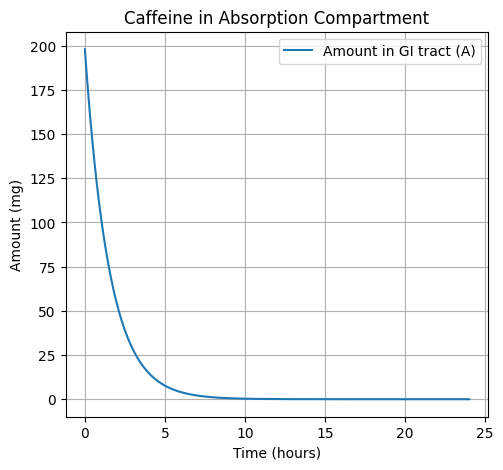

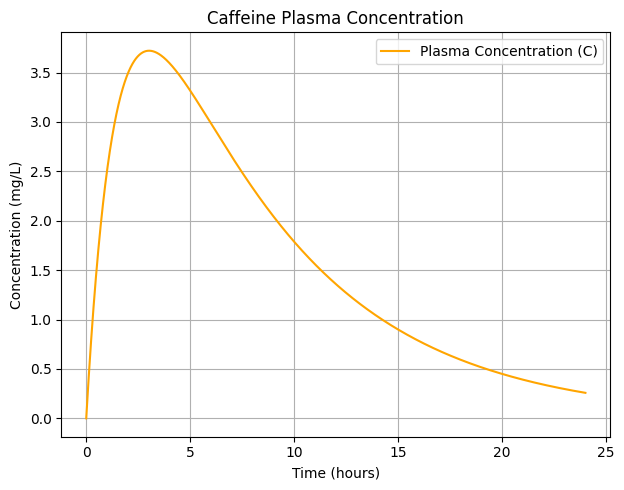

In [24]:
# Solve ODE for caffeine pharmacokinetics
time_vals = np.linspace(0, 86400, 10000)  # 1 day * 24 hr/day * 3600 sec/hr = 86400 sec
A0 = D * F  # initial amount in absorption compartment
C0 = 0  # initial plasma concentration
sol = sci.odeint(cafPK, [A0, C0], time_vals, args=(ka, th, Vd))
A, C = sol.T

# Plot results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(time_vals/3600, A, label='Amount in GI tract (A)')
plt.xlabel('Time (hours)')
plt.ylabel('Amount (mg)')
plt.title('Caffeine in Absorption Compartment')
plt.legend()
plt.grid(True)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
plt.plot(time_vals/3600, C, label='Plasma Concentration (C)', color='orange')
plt.xlabel('Time (hours)')
plt.ylabel('Concentration (mg/L)')
plt.title('Caffeine Plasma Concentration')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()